reparameterization -> ngubah variable yang totally random menjadi semi random agar bisa diaba pola (gradient)

In [32]:
#imports
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.data import Dataset




In [33]:
#load img

DATASET_PATH = "./dataset/"
images = []

for filename in os.listdir(DATASET_PATH):
    img = load_img(f"{DATASET_PATH}/{filename}", target_size=(64, 64))
    img = img_to_array(img)
    images.append(img)


In [34]:
#initialization


#normalizing image
images = np.asarray(images).astype(np.float32) / 255.0

#splitting
x_train = images[:-10] #ambil semua kecuali 10 terakhir 
x_test = images[-10:]

IMAGE_ORIGINAL_SHAPE = x_train.shape[1:]
IMAGE_SIZE = IMAGE_ORIGINAL_SHAPE[0] * IMAGE_ORIGINAL_SHAPE[1]
IMAGE_ORIGINAL_SHAPE[2]

LATENT_DIM = 16
HIDDEN_DIM = 128
MAX_EPOCHS = 10
LEARNING_RATE = 0.0001
BATCH_SIZE = 8

print(f"Image size: {IMAGE_SIZE}")
print(f"Image original shape: {IMAGE_ORIGINAL_SHAPE}")
print(f"Training size: {len(x_train)}")
print(f"Testing size: {len(x_test)}")



Image size: 4096
Image original shape: (64, 64, 3)
Training size: 4990
Testing size: 10


In [35]:
#shuffling & training

dataset = Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(BATCH_SIZE*5).batch(BATCH_SIZE)

In [36]:
#model creation
class VAE(tf.keras.Model):
    def __init__(self, hidden_dim, latent_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)
        #encoder (3)
        self.fc1 = tf.keras.layers.Dense(hidden_dim, activation="relu") #learn pattern
        self.fc2 = tf.keras.layers.Dense(latent_dim) #output mean
        self.fc3 = tf.keras.layers.Dense(latent_dim) #output log variance

        #decoder(2)
        self.fc4 = tf.keras.layers.Dense(hidden_dim) #reconstruct image
        self.fc5 = tf.keras.layers.Dense(IMAGE_SIZE) #output hasil reconstruction

        #normalzation(2)
        self.encoder_batch_norm = tf.keras.layers.BatchNormalization()
        self.decoder_batch_norm = tf.keras.layers.BatchNormalization()

    def encode(self, x):
        x = self.encoder_batch_norm(x)
        h = self.fc1(x)

        return self.fc2(h), self.fc3(h)
    

    def reparameterization(self, mu, log_var):
        std = tf.exp(log_var * 0.5)
        eps = tf.random.normal(std.shape) #fully random

        return mu + std*eps
    
    def decode_logits(self, z): #masih raw
        h = self.fc4(z)
        h = self.fc5(h)

        return self.decoder_batch_norm(h)
    
    def decode(self,z): #sudah melalui activation fuctions
        return tf.nn.sigmoid(self.decode_logits(z))
    

    def call(self, input):
        mu, log_var = self.encode(input)
        z = self.reparameterization(mu, log_var)
        x_recon_logits = self.decode_logits(z)

        return x_recon_logits, mu, log_var





In [37]:
model = VAE(HIDDEN_DIM, LATENT_DIM)
model(tf.zeros((BATCH_SIZE, IMAGE_SIZE)))
model.summary()

optimizer = tf.optimizers.Adam(LEARNING_RATE)

Model: "vae_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            multiple                  524416    
                                                                 
 dense_16 (Dense)            multiple                  2064      
                                                                 
 dense_17 (Dense)            multiple                  2064      
                                                                 
 dense_18 (Dense)            multiple                  2176      
                                                                 
 dense_19 (Dense)            multiple                  528384    
                                                                 
 batch_normalization_6 (Batc  multiple                 16384     
 hNormalization)                                                 
                                                             

In [39]:
#training

loss_history = [] #nyimpan perbedaan hasil dari reconstruction
kl_div_history = [] #nyimpan perbedaan mean dan log_var -> N(0,1)
for epoch in range (MAX_EPOCHS):
    for x in dataset:
        x = tf.reshape(x, [-1, IMAGE_SIZE])

        with tf.GradientTape() as tape:
            x_recon_logits, mu, log_var = model(x)

            reconstruction_loss = tf.nn.sigmoid_cross_entropy_with_logits(
                labels = x, logits = x_recon_logits
            )

            reconstruction_loss = tf.reduce_sum(reconstruction_loss) / BATCH_SIZE

            kl_div = -0.5*tf.reduce_sum(
                1 + log_var - tf.square(mu) - tf.exp(log_var), axis = -1
            )
            kl_div = tf.reduce_mean(kl_div)

            loss = tf.reduce_mean(reconstruction_loss + kl_div)
        
        gredients = tape.gradient(loss, model.trainable_variables)

        #clipping, menghindari gradient explosion
        gredients = [tf.clip_by_norm(g, 15) for g in gredients]

        optimizer.apply_gradients(zip(gredients, model.trainable_variables))
    print(f"Epochs[{epoch+1} /{MAX_EPOCHS}] Reconstruction Loss {reconstruction_loss} KL_DIV: {kl_div}")

    loss_history.append(reconstruction_loss)
    kl_div_history.append(kl_div)
















Epochs[1 /10] Reconstruction Loss 2706.09814453125 KL_DIV: 130.6207733154297
Epochs[2 /10] Reconstruction Loss 2450.52880859375 KL_DIV: 94.38148498535156
Epochs[3 /10] Reconstruction Loss 2649.1123046875 KL_DIV: 81.06941223144531
Epochs[4 /10] Reconstruction Loss 2208.178466796875 KL_DIV: 63.41072463989258
Epochs[5 /10] Reconstruction Loss 2490.9375 KL_DIV: 73.65620422363281
Epochs[6 /10] Reconstruction Loss 2805.30810546875 KL_DIV: 67.98912048339844
Epochs[7 /10] Reconstruction Loss 2338.24462890625 KL_DIV: 60.40620422363281
Epochs[8 /10] Reconstruction Loss 2870.416748046875 KL_DIV: 58.57444763183594
Epochs[9 /10] Reconstruction Loss 2636.212158203125 KL_DIV: 67.88014221191406
Epochs[10 /10] Reconstruction Loss 2845.566650390625 KL_DIV: 59.93199920654297


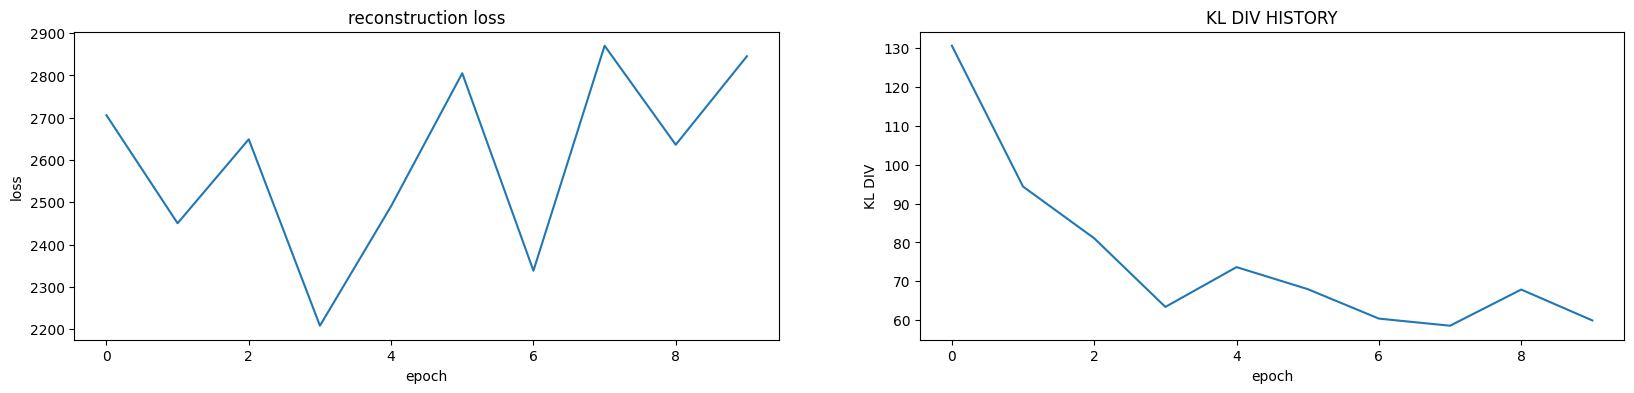

In [40]:
#plotting

plt.figure(figsize = (20, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("reconstruction loss")

#plotting

plt.subplot(1, 2, 2)
plt.plot(kl_div_history)
plt.xlabel("epoch")
plt.ylabel("KL DIV")
plt.title("KL DIV HISTORY")

plt.show()

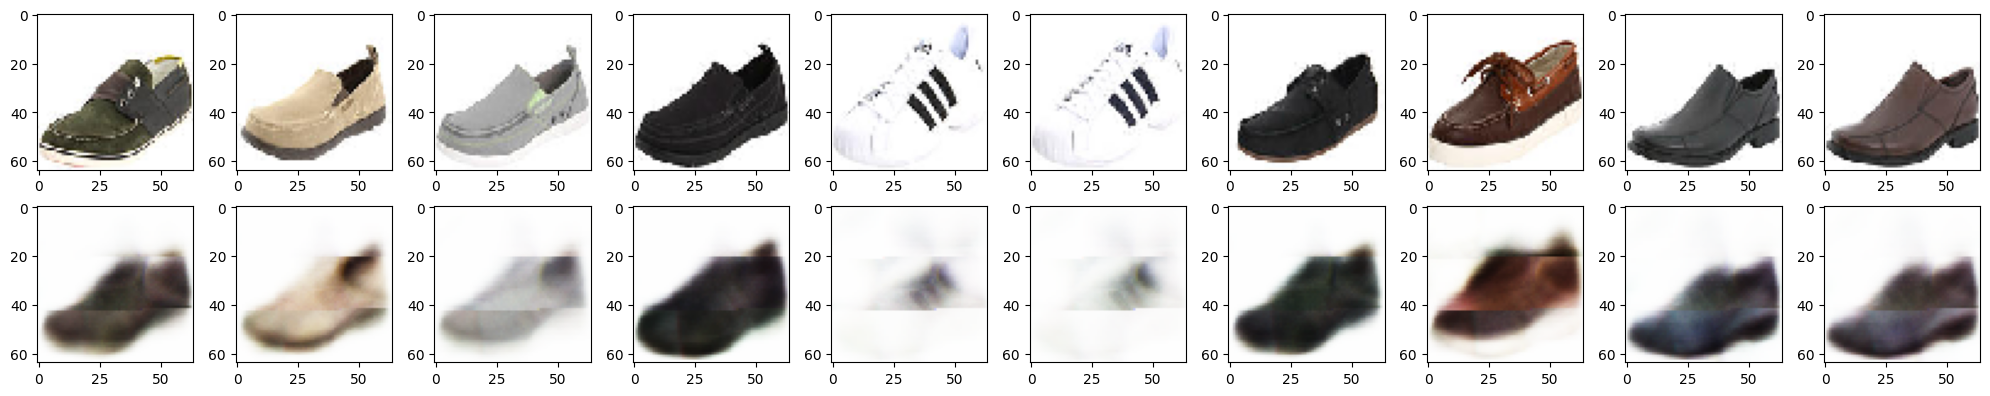

In [48]:
#show result

mu, log_var = model.encode(x_test.reshape(-1, IMAGE_SIZE))
z = model.reparameterization(mu, log_var)
out = model.decode(z)

out = tf.reshape(out, [-1, IMAGE_ORIGINAL_SHAPE[0], IMAGE_ORIGINAL_SHAPE[1], IMAGE_ORIGINAL_SHAPE[2]]).numpy() * 255.0

out = out.astype(np.uint8)


plt.figure(figsize = (20, 4))

test_size = len(x_test)
for index in range(test_size):
    plt.subplot(2, test_size, index+1)
    plt.imshow(x_test[index])

for index in range(test_size):
    plt.subplot(2, test_size, test_size + index+1)
    plt.imshow(out[index])

plt.tight_layout()
plt.show()
